In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def carregar_titanic_dataset():
    caminho_arquivo = Path('datasets/titanic.tgz')
    if not caminho_arquivo.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://homl.info/titanic.tgz'
        urllib.request.urlretrieve(url, caminho_arquivo)
        with tarfile.open(caminho_arquivo) as titanic_tarball:
            titanic_tarball.extractall(path='datasets', filter='data')
        
    treino = pd.read_csv(Path("datasets/titanic/train.csv"))
    teste = pd.read_csv(Path("datasets/titanic/test.csv"))
    return treino, teste

In [2]:
titanic_treino, titanic_teste = carregar_titanic_dataset()
titanic_treino.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Primeiras Impressões ##

Idade e Cabine possuem valores nulos

In [3]:
titanic_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Há mais pessoas de primeira classe do que de segunda

In [4]:
titanic_treino['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Há mais homens que mulheres

In [5]:
titanic_treino['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

A maioria dos passeiros estavam desacompanhados

In [6]:
#Irmãos e esposas
print(titanic_treino['SibSp'].value_counts())
print(f'Percentual de passageiros sem irmão e/ou esposas: {(titanic_treino['SibSp']==0).astype(int).sum()/len(titanic_treino['SibSp']):.1%}')

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Percentual de passageiros sem irmão e/ou esposas: 68.2%


In [7]:
#Pais e Filhos
print(titanic_treino['Parch'].value_counts())
print(f'Percentual de passageiros sem pais e/ou filhos: {(titanic_treino['Parch']==0).astype(int).sum()/len(titanic_treino['Parch']):.1%}')

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Percentual de passageiros sem pais e/ou filhos: 76.1%


In [8]:
#Local do Embarque
titanic_treino["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Podemos extrair a informação alfabética da cabine

In [9]:
print(titanic_treino['Cabin'].value_counts()[:8])
titanic_treino["Cabin"].str[0].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
E101           3
C22 C26        3
F33            3
Name: count, dtype: int64


Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Para os valores nulos de idade, pode-se usar a média global de idade ou uma média de idade por grupo de interesse.

In [10]:
titanic_treino['Age'].describe()

count    714.000000
mean      29.699113
std       14.526507
min        0.416700
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [11]:
titanic_treino.groupby(["Sex","Pclass"])["Age"].describe()

count       mean        std     min     25%   50%    75%   max
Sex    Pclass                                                                
female 1        85.0  34.611765  13.612052  2.0000  23.000  35.0  44.00  63.0
       2        74.0  28.722973  12.872702  2.0000  22.250  28.0  36.00  57.0
       3       102.0  21.750000  12.729964  0.7500  14.125  21.5  29.75  63.0
male   1       101.0  41.281353  15.139658  0.9167  30.000  40.0  51.00  80.0
       2        99.0  30.740740  14.793826  0.6667  23.000  30.0  36.75  70.0
       3       253.0  26.507576  12.159542  0.4167  20.000  25.0  33.00  74.0

Os preços dos ingressos está apresentando um comportamento estranho, o desvio padrão por classe e local de embarque é muito alto, isso acontece porque os ingressos podem ser vendidos para uma pessoa ou várias.

In [12]:
titanic_treino.groupby(["Pclass","Embarked"])["Fare"].describe()

count        mean        std      min      25%      50%  \
Pclass Embarked                                                            
1      C          85.0  104.718529  99.093935  26.5500  49.5000  78.2667   
       Q           2.0   90.000000   0.000000  90.0000  90.0000  90.0000   
       S         127.0   70.364862  58.811278   0.0000  29.2500  52.0000   
2      C          17.0   25.358335  11.345067  12.0000  13.8625  24.0000   
       Q           3.0   12.350000   0.000000  12.3500  12.3500  12.3500   
       S         164.0   20.327439  13.630741   0.0000  13.0000  13.5000   
3      C          66.0   11.214083   4.871528   4.0125   7.2292   7.8958   
       Q          72.0   11.183393   6.721677   6.7500   7.7500   7.7500   
       S         353.0   14.644083  13.276609   0.0000   7.8542   8.0500   

                        75%       max  
Pclass Embarked                        
1      C         110.883300  512.3292  
       Q          90.000000   90.0000  
       S          83.475000  263.0000  
2      C          37.004200   41.5792  
       Q          12.350000   12.3500  
       S          26.000000   73.5000  
3      C          14.458300   22.3583  
       Q          10.218725   29.1250  
       S          16.100000   69.5500

In [13]:
titanic_treino["Ticket"].value_counts().head()

Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64

In [14]:
titanic_treino[titanic_treino['Ticket'] == '347082'][["Ticket", "Name", "Pclass", "Parch", "SibSp", "Fare"]]

,Ticket,Name,Pclass,Parch,SibSp,Fare
13,347082,"Andersson, Mr. Anders Johan",3,5,1,31.275
119,347082,"Andersson, Miss. Ellis Anna Maria",3,2,4,31.275
541,347082,"Andersson, Miss. Ingeborg Constanzia",3,2,4,31.275
542,347082,"Andersson, Miss. Sigrid Elisabeth",3,2,4,31.275
610,347082,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",3,5,1,31.275
813,347082,"Andersson, Miss. Ebba Iris Alfrida",3,2,4,31.275
850,347082,"Andersson, Master. Sigvard Harald Elias",3,2,4,31.275


In [15]:
titanic_treino.loc[titanic_treino.groupby("Ticket")["Fare"].transform("count")>1, ["Ticket", "Fare", "Pclass", "Embarked"]].assign(
    quantidade_ticket = titanic_treino.groupby("Ticket")["Ticket"].transform("count"),
    preco_por_pessoa = titanic_treino["Fare"]/titanic_treino.groupby("Ticket")["Ticket"].transform("count")
    ).sort_values(["Pclass", "Embarked"], ascending=False).head(8)

,Ticket,Fare,Pclass,Embarked,quantidade_ticket,preco_por_pessoa
7,349909,21.0750,3,S,4,5.268750
8,347742,11.1333,3,S,3,3.711100
10,PP 9549,16.7000,3,S,2,8.350000
13,347082,31.2750,3,S,7,4.467857
24,349909,21.0750,3,S,4,5.268750
25,347077,31.3875,3,S,4,7.846875
38,345764,18.0000,3,S,2,9.000000
49,349237,17.8000,3,S,2,8.900000


In [16]:
titanic_treino.loc[titanic_treino.groupby("Ticket")["Fare"].transform("count")>1, ["Ticket", "Fare", "Pclass", "Embarked"]].assign(
    quantidade_ticket = titanic_treino.groupby("Ticket")["Ticket"].transform("count"),
    preco_por_pessoa = titanic_treino["Fare"]/titanic_treino.groupby("Ticket")["Ticket"].transform("count")
    ).groupby(["Pclass","Embarked"])["preco_por_pessoa"].describe()

count       mean        std        min        25%        50%  \
Pclass Embarked                                                                 
1      C          50.0  56.801862  39.391591  15.500000  34.650000  43.065625   
       Q           2.0  45.000000   0.000000  45.000000  45.000000  45.000000   
       S          65.0  39.170043  16.191509  15.500000  26.550000  33.300000   
2      C           9.0  14.739356   2.393249  12.000000  13.859733  13.859733   
       S          68.0  11.731618   5.573514   0.000000   8.750000  11.500000   
3      C          24.0   7.320833   1.748439   4.814575   6.825538   7.228125   
       Q          16.0   7.689063   1.803145   5.825000   5.825000   7.750000   
       S         108.0   7.137056   2.395144   0.000000   5.268750   7.816667   

                       75%        max  
Pclass Embarked                        
1      C         56.881250  170.77640  
       Q         45.000000   45.00000  
       S         45.211100   82.43335  
2      C         15.035400   18.50210  
       S         13.125000   32.50000  
3      C          7.684887   11.17915  
       Q          8.050000   11.62500  
       S          8.140621   12.07500

## Pré-Processamento ##

In [17]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np 

#Para ter estabilidade entre dados de treino e teste o ideal é padronizar o valor de idade por grupo pelos dados de treino
class ImputadorIdadePorGrupo(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.medias_por_grupo_ = {}
        self.media_global_ = 0

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=['Age','Sex','Pclass']).copy()
        X_df['Age'] = pd.to_numeric(X_df['Age'], errors='coerce')
        self.media_global_ = X_df['Age'].mean()
        grupos = X_df.groupby(['Sex', 'Pclass'])['Age'].mean()
        self.medias_por_grupo_ = grupos.to_dict()
        return self
    
    def transform(self, X):
        X_df = pd.DataFrame(X, columns=['Age','Sex','Pclass']).copy()
        X_df['Age'] = pd.to_numeric(X_df['Age'], errors='coerce')
        def preencher_linha(linha):
            if pd.isna(linha['Age']):
                chave_grupo = (linha['Sex'], linha['Pclass'])
                return self.medias_por_grupo_.get(chave_grupo, self.media_global_)
            return linha['Age']
        
        idade_preenchida = X_df.apply(preencher_linha, axis=1)
        return idade_preenchida.values.reshape(-1, 1)
    
    def get_feature_names_out(self, input_features=None):
        return np.array(['idade'], dtype=object)
    
def extrair_pronome_tratamento(df:pd.DataFrame):
    return df.Name.str.extract(' ([A-Za-z]+)\.', expand=False).values.reshape(-1,1)

def pronome_tratamento_pipeline():
    return make_pipeline(
        FunctionTransformer(extrair_pronome_tratamento, feature_names_out=lambda self,input_features: ["tratamento"]),
        OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    )

def calc_preco_pessoa(df:pd.DataFrame):
    return (df["Fare"] / df.groupby("Ticket")["Ticket"].transform("count")).values.reshape(-1,1)

def preco_pessoa_pipeline():
    return make_pipeline(
        FunctionTransformer(calc_preco_pessoa, feature_names_out=lambda self,input_features: ["ticket"]),
        StandardScaler()
    )
def alfa_cabine(X:pd.DataFrame):
    #preencher os valores desconhecidos com U para manter o padrão de leitura de um caracter
    return X["Cabin"].fillna('U').str[0].values.reshape(-1,1)

def cabine_pipeline():
    return make_pipeline(
        FunctionTransformer(alfa_cabine, feature_names_out='one-to-one'),
        OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    )

def somar_dados(df:pd.DataFrame):
    return (df["SibSp"] + df["Parch"]).values.reshape(-1,1)

preprocessamento = ColumnTransformer([
    ("idade", ImputadorIdadePorGrupo(),["Age","Sex","Pclass"]),
    ("tratamento", pronome_tratamento_pipeline(),["Name"]),
    ("preco_pessoa", preco_pessoa_pipeline(),["Fare","Ticket"]),
    ("Sexo_Feminino", OrdinalEncoder(categories=[["male","female"]]),["Sex"]),
    ("Qtd_familiares", FunctionTransformer(somar_dados, feature_names_out=lambda self,input_features:["Qtd_familiares"]), ["SibSp","Parch"]),
    ('cabine', cabine_pipeline(), ['Cabin']),
    ('pc',OneHotEncoder(sparse_output=False,handle_unknown='ignore'), ["Pclass"]),
    ('fare_scaled', StandardScaler(), ['Fare']),
    ("originais", "passthrough", ['PassengerId', 'SibSp', 'Parch'])
],
remainder="drop",
verbose_feature_names_out=True)

titanic_preparado = preprocessamento.fit_transform(titanic_treino)
pd.DataFrame(titanic_preparado[:5], columns=preprocessamento.get_feature_names_out())

,idade__idade,tratamento__tratamento_Capt,tratamento__tratamento_Col,tratamento__tratamento_Countess,tratamento__tratamento_Don,tratamento__tratamento_Dr,tratamento__tratamento_Jonkheer,tratamento__tratamento_Lady,tratamento__tratamento_Major,tratamento__tratamento_Master,...,cabine__Cabin_G,cabine__Cabin_T,cabine__Cabin_U,pc__Pclass_1,pc__Pclass_2,pc__Pclass_3,fare_scaled__Fare,originais__PassengerId,originais__SibSp,originais__Parch
0,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,-0.502445,1.0,1.0,0.0
1,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.786845,2.0,1.0,0.0
2,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,-0.488854,3.0,0.0,0.0
3,35.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.420730,4.0,1.0,0.0
4,35.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,-0.486337,5.0,0.0,0.0


## Seleção e Treinamento de Modelos ##

Definir uma linha de base com o dummy classifier, treinar alguns modelos e medir a qualidade de cada, após isso definir um modelo para realizar um `Grid Search`

In [18]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix

y = titanic_treino.Survived
n_random = 42
dummy_pipeline = make_pipeline(preprocessamento, DummyClassifier(random_state=n_random))
logistic_pipeline = make_pipeline(preprocessamento, LogisticRegression(random_state=n_random, max_iter=2000))
sgd_pipeline = make_pipeline(preprocessamento, SGDClassifier(random_state=n_random))

dummy_cross_val_score = cross_val_score(dummy_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
logistic_cross_val_score = cross_val_score(logistic_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
sgd_cross_val_score = cross_val_score(sgd_pipeline, titanic_treino, y, scoring='accuracy', cv=10)


dummy_cross_val_score.mean(), logistic_cross_val_score.mean(), sgd_cross_val_score.mean()

(np.float64(0.616167290886392),
 np.float64(0.8294382022471909),
 np.float64(0.5554307116104868))

In [19]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier

random_forest_pipeline = make_pipeline(preprocessamento,RandomForestClassifier(random_state=n_random))
hist_gradient_pipeline = make_pipeline(preprocessamento,HistGradientBoostingClassifier(random_state=n_random))
gradient_boosting_pipeline = make_pipeline(preprocessamento,GradientBoostingClassifier(random_state=n_random))

random_forest_score = cross_val_score(random_forest_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
hist_gradient_score = cross_val_score(hist_gradient_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
gradient_boosting_score = cross_val_score(gradient_boosting_pipeline, titanic_treino, y, scoring='accuracy', cv=10)

random_forest_score.mean(), hist_gradient_score.mean(), gradient_boosting_score.mean()

(np.float64(0.828314606741573),
 np.float64(0.7890262172284646),
 np.float64(0.8036329588014981))

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier

gaussian_pipeline = make_pipeline(preprocessamento, GaussianNB())
knn_pipeline = make_pipeline(preprocessamento, KNeighborsClassifier(n_neighbors=1))
ridge_pipeline = make_pipeline(preprocessamento, RidgeClassifier(random_state=n_random))

gaussian_score = cross_val_score(gaussian_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
knn_score = cross_val_score(knn_pipeline, titanic_treino, y, scoring='accuracy', cv=10)
ridge_score = cross_val_score(ridge_pipeline, titanic_treino, y, scoring='accuracy', cv=10)

gaussian_score.mean(),knn_score.mean(),ridge_score.mean()



(np.float64(0.7363295880149813),
 np.float64(0.46016229712858936),
 np.float64(0.8294382022471909))

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

modelos_dados = []

for nome_modelo, modelo_pipeline in zip(['LogisticRegression', 'RandomForestClassifier', 'GradientBoostingClassifier', 'RidgeClassifier'], 
                                 [logistic_pipeline, random_forest_pipeline, gradient_boosting_pipeline, ridge_pipeline]):
    if nome_modelo == 'RidgeClassifier':
        probas = cross_val_predict(modelo_pipeline, titanic_treino, y, cv=10, method='decision_function')
        predicao = (probas >= 0.0).astype(int)
    else:
        # Pega apenas a probabilidade da classe positiva (índice 1)
        probas = cross_val_predict(modelo_pipeline, titanic_treino, y, cv=10, method='predict_proba')[:, 1]
        predicao = (probas >= 0.5).astype(int)

    f1 = f1_score(y,predicao)
    precisao = precision_score(y,predicao)
    sensibilidade = recall_score(y, predicao)
    roc_score = roc_auc_score(y, probas)
    pcr=precision_recall_curve(y, probas)
    print(f'Metricas do modelo {nome_modelo}:\n\tF1 Score : {f1:.4f} \n\tPrecisão : {precisao:.4f}\n\tRecall   : {sensibilidade:.4f}\n\tROC Score: {roc_score:.4f}\n')

    info_modelo = {'nome_modelo': nome_modelo, 
                   'predicao': predicao,
                   'probas':probas,
                   'precisao_score': precisao, 
                   'recall_score': sensibilidade, 
                   'roc_auc_score': roc_score, 
                   'precision_recall_curve': pcr}
    modelos_dados.append(info_modelo)

Metricas do modelo LogisticRegression:
	F1 Score : 0.7738 
	Precisão : 0.7879
	Recall   : 0.7602
	ROC Score: 0.8662

Metricas do modelo RandomForestClassifier:
	F1 Score : 0.7704 
	Precisão : 0.7969
	Recall   : 0.7456
	ROC Score: 0.8638

Metricas do modelo GradientBoostingClassifier:
	F1 Score : 0.7360 
	Precisão : 0.7601
	Recall   : 0.7135
	ROC Score: 0.8479

Metricas do modelo RidgeClassifier:
	F1 Score : 0.7711 
	Precisão : 0.7950
	Recall   : 0.7485
	ROC Score: 0.8643



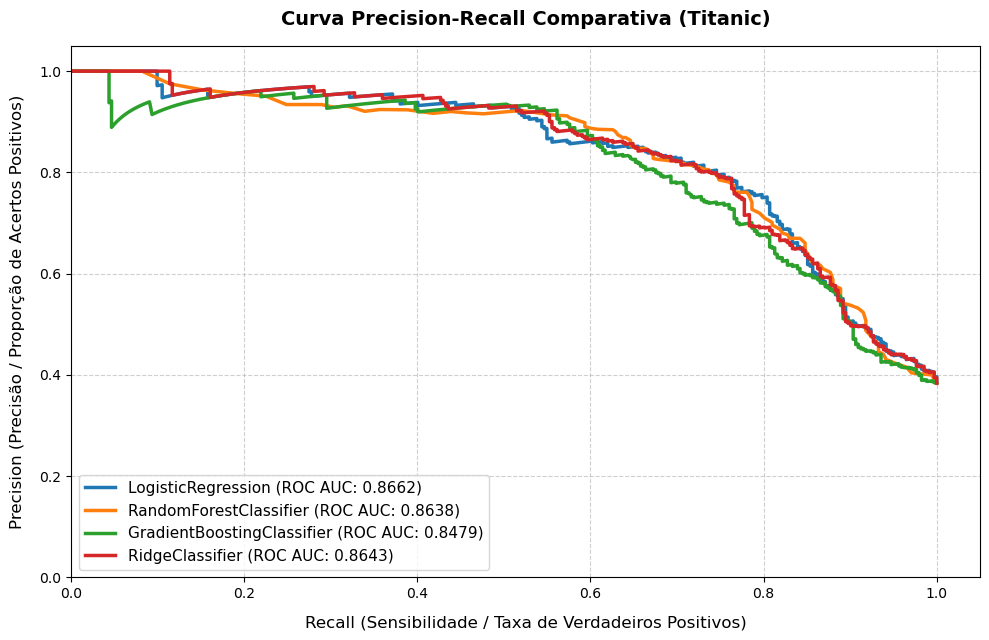

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6.5))

for modelo in modelos_dados:
    precisions, recalls, _ = modelo['precision_recall_curve']
    plt.plot(recalls, precisions, label=f"{modelo['nome_modelo']} (ROC AUC: {modelo['roc_auc_score']:.4f})", linewidth=2.5)

plt.xlabel('Recall (Sensibilidade / Taxa de Verdadeiros Positivos)', fontsize=12, labelpad=10)
plt.ylabel('Precision (Precisão / Proporção de Acertos Positivos)', fontsize=12, labelpad=10)
plt.title('Curva Precision-Recall Comparativa (Titanic)', fontsize=14, pad=15, fontweight='bold')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



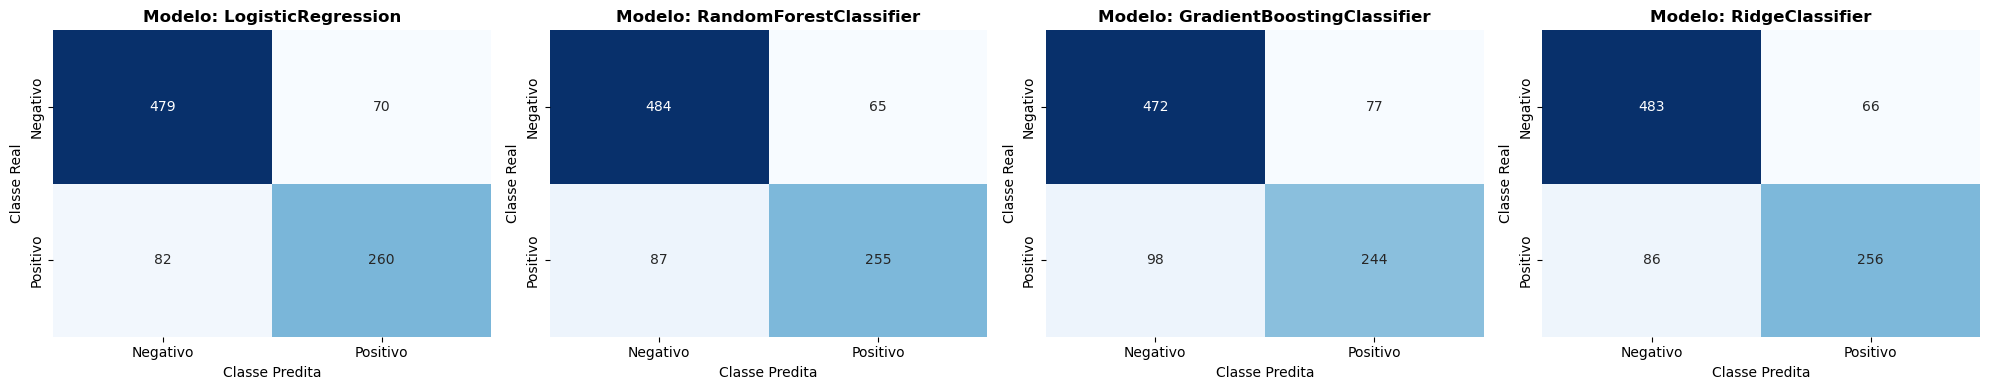

In [23]:
import seaborn as sns

fig, axes = plt.subplots(1, len(modelos_dados), figsize=(5 * len(modelos_dados), 4))


for ax, modelo in zip(axes, modelos_dados):
    cm = confusion_matrix(y, modelo['predicao'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Negativo', 'Positivo'], 
                yticklabels=['Negativo', 'Positivo'])
    
    ax.set_title(f"Modelo: {modelo['nome_modelo']}", fontsize=12, fontweight='bold')
    ax.set_ylabel('Classe Real')
    ax.set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

    


In [24]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2', None],
        'C': np.logspace(-4, 4, 20),      
        'tol': [1e-4, 1e-3, 1e-2],       
        'max_iter': [100, 500, 1000, 2000, 2500, 3000] 
    },
    {
        'solver': ['newton-cg'],
        'penalty': ['l2', None],
        'C': np.logspace(-4, 4, 20),
        'tol': [1e-5, 1e-4, 1e-3],       
        'max_iter': [100, 500, 1000, 2000, 2500, 3000]  
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 500, 1000, 2000, 2500, 3000]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', None],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [500, 1000, 2000, 2500, 3000]  
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.2, 0.5, 0.8], 
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [2000, 2500, 3000]  
    }
]


grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=n_random),
    param_grid=param_grid,
    cv=10,           
    scoring='accuracy', 
    n_jobs=-1        
)

grid_search_lr.fit(preprocessamento.fit_transform(titanic_treino), y)

print("Melhores parâmetros:", grid_search_lr.best_params_)
print("Melhor score:", grid_search_lr.best_score_)

top_10_modelos = pd.DataFrame(grid_search_lr.cv_results_).sort_values(by="mean_test_score", ascending=False).head(10)

colunas_param = ['param_solver', 'param_penalty', 'param_max_iter', 'param_C', 'mean_test_score', 'std_test_score']

display(top_10_modelos[colunas_param])


Melhores parâmetros: {'C': np.float64(4.281332398719396), 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs', 'tol': 0.0001}
Melhor score: 0.8338951310861423


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,param_solver,param_penalty,param_max_iter,param_C,mean_test_score,std_test_score
396,lbfgs,l2,100,4.281332,0.833895,0.033998
397,lbfgs,l2,100,4.281332,0.833895,0.033998
668,lbfgs,l2,2000,3792.690191,0.832772,0.030335
433,lbfgs,l2,100,11.288379,0.832772,0.031157
656,lbfgs,l2,500,3792.690191,0.832772,0.030335
662,lbfgs,l2,1000,3792.690191,0.832772,0.030335
432,lbfgs,l2,100,11.288379,0.832772,0.031157
674,lbfgs,l2,2500,3792.690191,0.832772,0.030335
680,lbfgs,l2,3000,3792.690191,0.832772,0.030335
330,lbfgs,l2,500,0.615848,0.831660,0.032111


In [25]:
feature_names = preprocessamento.get_feature_names_out()
coeficientes = grid_search_lr.best_estimator_.coef_[0]

importancia_lr = pd.DataFrame({
    'feature': feature_names,
    'coef': coeficientes,
    'abs_coef': np.abs(coeficientes)
}).sort_values('abs_coef', ascending=False)

importancia_lr

,feature,coef,abs_coef
9,tratamento__tratamento_Master,1.484831,1.484831
19,Sexo_Feminino__Sex,1.473095,1.473095
30,pc__Pclass_1,1.348058,1.348058
14,tratamento__tratamento_Mrs,1.161181,1.161181
13,tratamento__tratamento_Mr,-1.158678,1.158678
25,cabine__Cabin_E,0.784185,0.784185
24,cabine__Cabin_D,0.620363,0.620363
29,cabine__Cabin_U,-0.600163,0.600163
32,pc__Pclass_3,-0.561768,0.561768
31,pc__Pclass_2,0.416208,0.416208


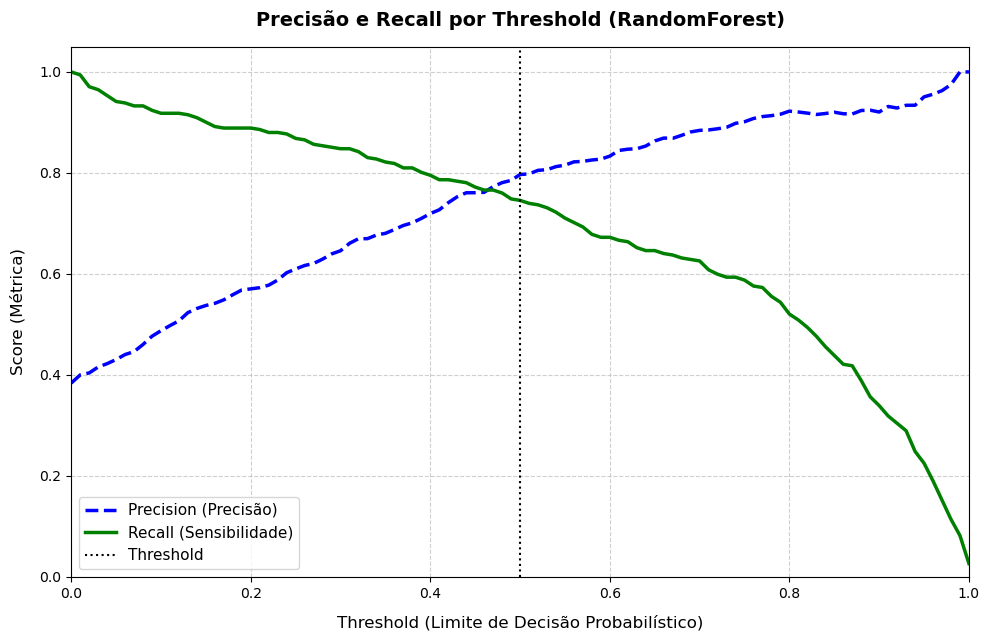

In [26]:
rf_dados = next((m for m in modelos_dados if m['nome_modelo'] == 'RandomForestClassifier'), None)


p, r, t = rf_dados['precision_recall_curve']

plt.figure(figsize=(10, 6.5))
plt.plot(t, p[:-1], 'b--', label='Precision (Precisão)', linewidth=2.5)
plt.plot(t, r[:-1], 'g-', label='Recall (Sensibilidade)', linewidth=2.5)
plt.vlines(0.5,0,1.05,'k','dotted',label='Threshold')

plt.xlabel('Threshold (Limite de Decisão Probabilístico)', fontsize=12, labelpad=10)
plt.ylabel('Score (Métrica)', fontsize=12, labelpad=10)
plt.title('Precisão e Recall por Threshold (RandomForest)', fontsize=14, pad=15, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 500],   
    'max_depth': [None, 5, 10, 15],        
    'min_samples_split': [2, 5, 10, 14],   
    'min_samples_leaf': [1, 2, 4, 6],      
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=n_random),
    param_grid=param_grid,
    cv=10,
    verbose=2,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(titanic_preparado, y)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor score:", grid_search.best_score_)

Fitting 10 folds for each of 256 candidates, totalling 2560 fits
Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Melhor score: 0.8428838951310862


In [28]:
resultados = pd.DataFrame(grid_search.cv_results_)
top_10_modelos = resultados.sort_values(by="mean_test_score", ascending=False).head(10)

colunas_param = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                   'param_min_samples_leaf','mean_test_score', 'std_test_score']

display(top_10_modelos[colunas_param])

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
10,200,None,10,1,0.842884,0.046285
137,100,10,10,1,0.841785,0.042908
24,50,None,10,2,0.840649,0.045082
22,200,None,5,2,0.838427,0.048847
161,100,10,2,4,0.838427,0.037434
165,100,10,5,4,0.838427,0.037434
142,200,10,14,1,0.838414,0.042258
25,100,None,10,2,0.838414,0.044014
145,100,10,2,2,0.838402,0.042020
215,500,15,5,2,0.837316,0.050329


In [29]:
melhor_modelo = grid_search.best_estimator_
importancia_preditores = pd.DataFrame(index=preprocessamento.get_feature_names_out(), 
             data={'Importancia':melhor_modelo.feature_importances_}
             ).sort_values('Importancia', ascending=False)
importancia_preditores

,Importancia
tratamento__tratamento_Mr,0.161726
Sexo_Feminino__Sex,0.152141
preco_pessoa__ticket,0.105757
fare_scaled__Fare,0.103844
originais__PassengerId,0.089532
idade__idade,0.087583
Qtd_familiares__Qtd_familiares,0.040452
tratamento__tratamento_Miss,0.040301
pc__Pclass_3,0.039614
tratamento__tratamento_Mrs,0.034570


Importância média dos preditores: 0.0270


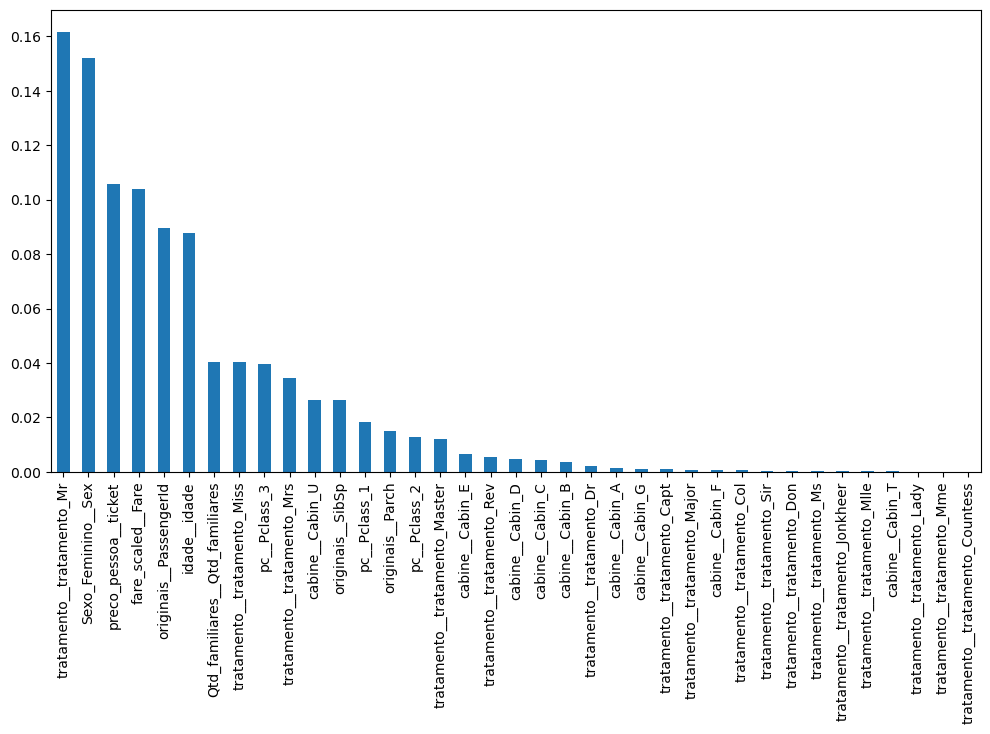

In [30]:
print(f'Importância média dos preditores: {importancia_preditores.Importancia.mean():.4f}')
importancia_preditores.plot(kind='bar', figsize=(12, 6), legend=False);

Acurácia de `84.28%` alcançada, porém a informação de cabine e vários pronomes de tratamento se mostraram irrelevantes para explicar a sobrevivência. De `idade` para `Qtd_familiares` há uma queda considerável de importâcia, podendo indicar que o limiar de preditores relevantes esteja nessa faixa. A média da importância de um preditor está em `0.027`, também poderia ser um valor de corte.

In [31]:
def pronome_tratamento_pipeline_II():
    return make_pipeline(
        FunctionTransformer(extrair_pronome_tratamento, feature_names_out=lambda self,input_features: ["tratamento"]),
        OneHotEncoder(sparse_output=False, handle_unknown='ignore', categories=[['Mr']])
    )
preprocessamento_II = ColumnTransformer([
    ("idade", ImputadorIdadePorGrupo(),["Age","Sex","Pclass"]),
    ("tratamento", pronome_tratamento_pipeline_II(),["Name"]),
    ("preco_pessoa", preco_pessoa_pipeline(),["Fare","Ticket"]),
    ("Sexo_Feminino", OrdinalEncoder(categories=[["male","female"]]),["Sex"]),
    ("Qtd_familiares", FunctionTransformer(somar_dados, feature_names_out=lambda self,input_features:["Qtd_familiares"]), ["SibSp","Parch"]),
    ('pc',OneHotEncoder(sparse_output=False,handle_unknown='ignore', categories=[['3']]), ["Pclass"]),
    ('fare_scaled', StandardScaler(), ['Fare']),
    ("originais", "passthrough", ['PassengerId'])
],
remainder="drop",
verbose_feature_names_out=True)

In [32]:
grid_search_II = GridSearchCV(
    estimator=RandomForestClassifier(random_state=n_random),
    param_grid=param_grid,
    cv=10,
    verbose=2,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_II.fit(preprocessamento_II.fit_transform(titanic_treino), y)

print("Melhores parâmetros:", grid_search_II.best_params_)
print("Melhor score:", grid_search_II.best_score_)

top_10_modelos = pd.DataFrame(grid_search_II.cv_results_).sort_values(by="mean_test_score", ascending=False).head(5)

colunas_param = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                   'param_min_samples_leaf','mean_test_score', 'std_test_score']

display(top_10_modelos[colunas_param])

Fitting 10 folds for each of 256 candidates, totalling 2560 fits
Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor score: 0.8552559300873908


,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score
129,100,10,2,1,0.855256,0.046575
130,200,10,2,1,0.851885,0.049058
5,100,None,5,1,0.850774,0.050089
135,500,10,5,1,0.850774,0.051088
131,500,10,2,1,0.850762,0.047560


In [33]:
pd.DataFrame(index=preprocessamento_II.get_feature_names_out(),data={'Importancia':grid_search_II.best_estimator_.feature_importances_}).sort_values('Importancia', ascending=False)

,Importancia
tratamento__tratamento_Mr,0.186484
preco_pessoa__ticket,0.153993
Sexo_Feminino__Sex,0.148544
fare_scaled__Fare,0.143399
originais__PassengerId,0.129153
idade__idade,0.124604
Qtd_familiares__Qtd_familiares,0.060568
pc__Pclass_3,0.053255


Acurácia de `85.52%` alcançada, o modelo teve uma melhora de `1.24%`, mantendo a praticamente a mesma estabilidade do modelo anterior.

Metricas REAIS do modelo (Via Cross-Validation):
	F1 Score : 0.8012 
	Precisão : 0.8469
	Recall   : 0.7602
	ROC Score: 0.8749
	Acurácia : 0.8552



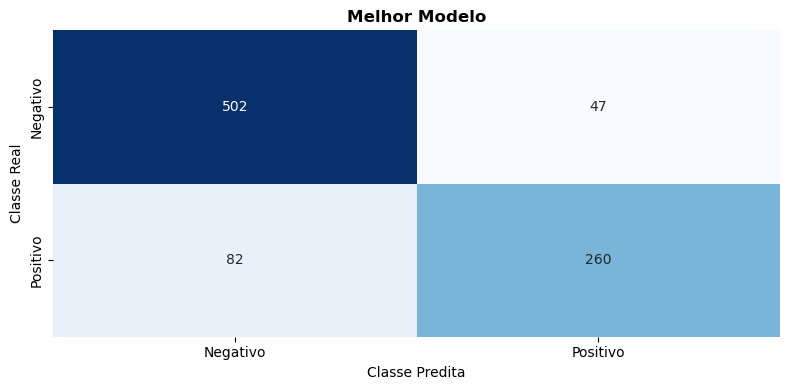

In [34]:
from sklearn.metrics import accuracy_score


melhor_modelo = grid_search_II.best_estimator_
predict_proba = cross_val_predict(melhor_modelo, preprocessamento_II.transform(titanic_treino), y, cv=10, method='predict_proba')[:, 1]

precission = precision_score(y, (predict_proba >= 0.5).astype(int))
recall = recall_score(y, (predict_proba >= 0.5).astype(int))
f1 = f1_score(y, (predict_proba >= 0.5).astype(int))
roc_auc = roc_auc_score(y, predict_proba)
acurracy = accuracy_score(y, (predict_proba >= 0.5).astype(int))

print(f'Metricas REAIS do modelo (Via Cross-Validation):\n'
      f'\tF1 Score : {f1:.4f} \n'
      f'\tPrecisão : {precission:.4f}\n'
      f'\tRecall   : {recall:.4f}\n'
      f'\tROC Score: {roc_auc:.4f}\n'
      f'\tAcurácia : {acurracy:.4f}\n')

fig, ax = plt.subplots(figsize=(8, 4))

cm = confusion_matrix(y, (predict_proba >= 0.5).astype(int))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Negativo', 'Positivo'], 
            yticklabels=['Negativo', 'Positivo'])
    
ax.set_title(f"Melhor Modelo", fontsize=12, fontweight='bold')
ax.set_ylabel('Classe Real')
ax.set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

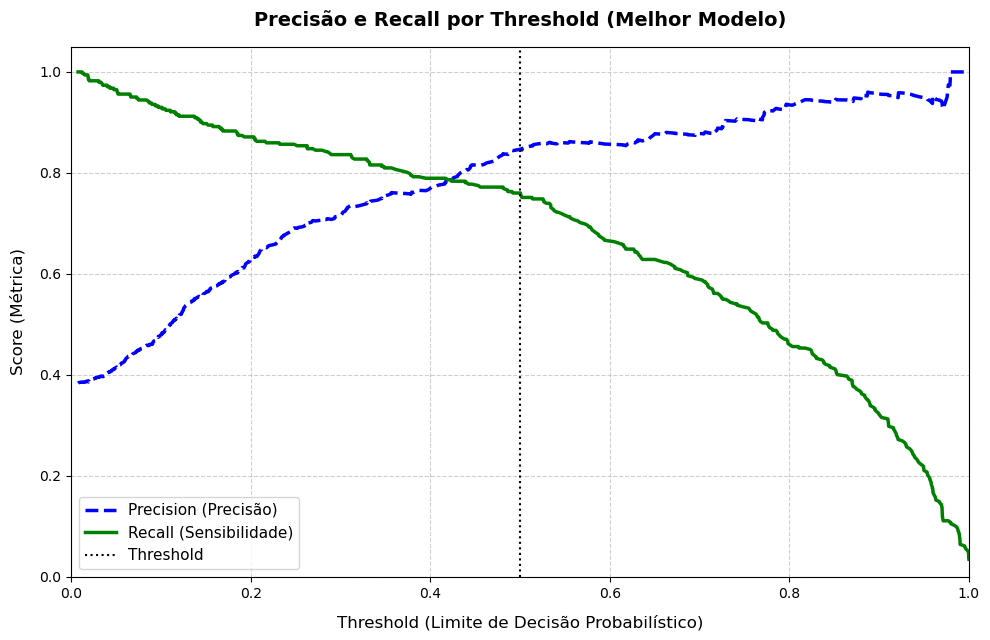

In [35]:

p, r, t = precision_recall_curve(y, predict_proba)

plt.figure(figsize=(10, 6.5))
plt.plot(t, p[:-1], 'b--', label='Precision (Precisão)', linewidth=2.5)
plt.plot(t, r[:-1], 'g-', label='Recall (Sensibilidade)', linewidth=2.5)
plt.vlines(0.5,0,1.05,'k','dotted',label='Threshold')

plt.xlabel('Threshold (Limite de Decisão Probabilístico)', fontsize=12, labelpad=10)
plt.ylabel('Score (Métrica)', fontsize=12, labelpad=10)
plt.title('Precisão e Recall por Threshold (Melhor Modelo)', fontsize=14, pad=15, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left", fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

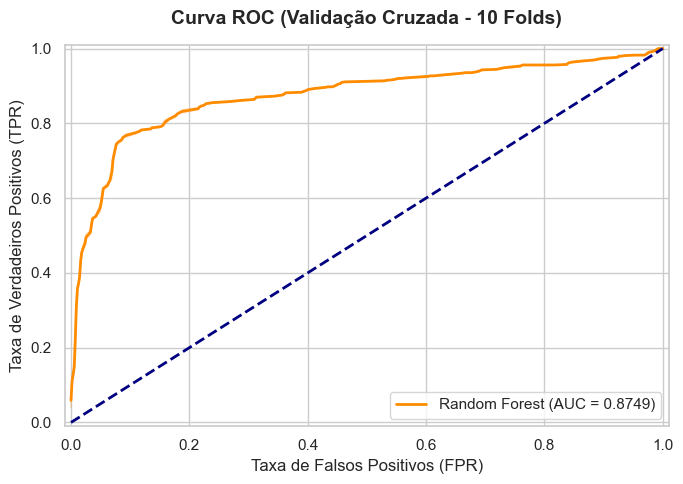

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y, predict_proba)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

sns.lineplot(x=fpr, y=tpr, label=f'Random Forest (AUC = {roc_auc:.4f})', color='darkorange', lw=2, ax=ax)

sns.lineplot(x=[0, 1], y=[0, 1], color='navy', lw=2, linestyle='--', ax=ax)

ax.set_title('Curva ROC (Validação Cruzada - 10 Folds)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()
